In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(ROOT, 'src'))
sys.path.insert(0, os.path.join(ROOT, 'code'))

import numpy as np
import pandas as pd
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles, make_moons
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

from visualization.plots import EmbeddingVisualizer

from data_meta_map.dataset2vec.config import Dataset2VecConfig, OptimizerConfig
from data_meta_map.dataset2vec.model import Dataset2Vec
from data_meta_map.dataset2vec_embedder import Dataset2VecEmbedder

pl.seed_everything(42, workers=True)
DATASET_TYPES = ("circles", "moons", "blobs")


Seed set to 42


## 1. Generate a balanced meta-dataset


In [3]:
def apply_noise(X: np.ndarray, rng: np.random.RandomState) -> np.ndarray:
    noise_scale = rng.uniform(0.05, 0.3)
    return X + rng.randn(*X.shape) * noise_scale


def make_dataframe(X: np.ndarray, y: np.ndarray) -> pd.DataFrame:
    df = pd.DataFrame(X, columns=[f"x{i}" for i in range(X.shape[1])])
    df["target"] = y.astype(np.float32)
    return df


def generate_dataset_by_type(
    ds_type: str,
    rng: np.random.RandomState,
    n_features: int = 2,
    subset_size: int = 200,
) -> pd.DataFrame:
    seed = int(rng.randint(0, 1_000_000))
    n_samples = 2 ** int(rng.choice([7, 8, 9]))

    if ds_type == "circles":
        X, y = make_circles(
            n_samples=n_samples,
            noise=0.05,
            factor=rng.uniform(0.3, 0.7),
            random_state=seed,
        )
    elif ds_type == "moons":
        X, y = make_moons(
            n_samples=n_samples,
            noise=0.05,
            random_state=seed,
        )
    elif ds_type == "blobs":
        X, y = make_blobs(
            n_samples=n_samples,
            centers=3,
            n_features=n_features,
            random_state=seed,
        )
    else:
        raise ValueError(f"Unknown dataset type: {ds_type}")

    if rng.uniform(0, 1) < 0.5:
        X = apply_noise(X, rng)

    X = StandardScaler().fit_transform(X)

    if len(X) > subset_size:
        idx = rng.choice(len(X), size=subset_size, replace=False)
        X, y = X[idx], y[idx]

    return make_dataframe(X, y)


def build_balanced_split(
    samples_per_type: int,
    random_state: int,
    subset_size: int = 200,
) -> tuple[list[pd.DataFrame], list[str]]:
    rng = np.random.RandomState(random_state)
    datasets: list[pd.DataFrame] = []
    labels: list[str] = []

    for ds_type in DATASET_TYPES:
        for _ in range(samples_per_type):
            datasets.append(
                generate_dataset_by_type(
                    ds_type=ds_type,
                    rng=rng,
                    subset_size=subset_size,
                )
            )
            labels.append(ds_type)

    order = rng.permutation(len(datasets))
    datasets = [datasets[i] for i in order]
    labels = [labels[i] for i in order]
    return datasets, labels


def describe_split(name: str, labels: list[str]) -> None:
    counts = pd.Series(labels).value_counts().reindex(DATASET_TYPES, fill_value=0)
    print(f"{name}: {len(labels)} datasets")
    print(counts.to_string())
    print()


In [4]:
TRAIN_PER_TYPE = 200
VAL_PER_TYPE = 60
TEST_PER_TYPE = 60

train_dfs, train_labels = build_balanced_split(TRAIN_PER_TYPE, random_state=42)
val_dfs, val_labels = build_balanced_split(VAL_PER_TYPE, random_state=123)
test_dfs, test_labels = build_balanced_split(TEST_PER_TYPE, random_state=321)

describe_split("Train", train_labels)
describe_split("Validation", val_labels)
describe_split("Test", test_labels)

print("Example dataset shape:", train_dfs[0].shape)


Train: 600 datasets
circles    200
moons      200
blobs      200

Validation: 180 datasets
circles    60
moons      60
blobs      60

Test: 180 datasets
circles    60
moons      60
blobs      60

Example dataset shape: (200, 3)


## 2. Create and train Dataset2Vec

In [6]:
model_config = Dataset2VecConfig(
    f_dense_hidden_size=16,
    f_res_hidden_size=16,
    f_res_n_layers=3,
    f_block_repetitions=3,
    f_out_size=32,
    g_layers_sizes=[16, 8, 8],
    h_dense_hidden_size=8,
    h_res_hidden_size=16,
    h_res_n_layers=3,
    h_block_repetitions=3,
    output_size=16,
)

optimizer_config = OptimizerConfig(
    gamma=1.0,
    learning_rate=3e-4,
    weight_decay=1e-4,
)

model = Dataset2Vec(config=model_config, optimizer_config=optimizer_config)
embedder = Dataset2VecEmbedder(model, max_epochs=3, batch_size=16, n_batches=100)
embedder.fit(
    train_dfs,
    val_data=val_dfs,
    trainer_kwargs=dict(
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=True,
        log_every_n_steps=1,
    ),
)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name | Type       | Params | Mode  | FLOPs
----------------------------------------------------
0 | f    | Sequential | 3.0 K  | train | 0    
1 | g    | Sequential | 736    | train | 0    
2 | h    | Sequential | 1.9 K  | train | 0    
----------------------------------------------------
5.6 K     Trainable params
0         Non-trainable params
5.6 K     Total params
0.023     Total estimated model params size (MB)
63        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=3` reached.


## 3. Embed train, validation and test datasets


In [8]:
def dataframe_to_tensors(df: pd.DataFrame) -> tuple[torch.Tensor, torch.Tensor]:
    X = torch.tensor(df.iloc[:, :-1].to_numpy(dtype=np.float32), dtype=torch.float32)
    y = torch.tensor(df.iloc[:, -1].to_numpy(dtype=np.float32), dtype=torch.float32).reshape(-1, 1)
    return X, y


def embed_datasets(embedder: Dataset2VecEmbedder, datasets: list[pd.DataFrame]) -> np.ndarray:
    device = next(embedder.model.parameters()).device
    embeddings = []
    embedder.model.eval()

    with torch.no_grad():
        for df in datasets:
            X, y = dataframe_to_tensors(df)
            embedding = (
                embedder.model(X.to(device), y.to(device))
                .detach()
                .cpu()
                .numpy()
                .reshape(-1)
            )
            embeddings.append(embedding)

    return np.vstack(embeddings)


def compute_centroids(embeddings: np.ndarray, labels: list[str]) -> dict[str, np.ndarray]:
    labels_arr = np.asarray(labels)
    return {
        label: embeddings[labels_arr == label].mean(axis=0)
        for label in DATASET_TYPES
    }


train_embeddings = embed_datasets(embedder, train_dfs)
val_embeddings = embed_datasets(embedder, val_dfs)
test_embeddings = embed_datasets(embedder, test_dfs)
train_centroids = compute_centroids(train_embeddings, train_labels)

print("Train embeddings:", train_embeddings.shape)
print("Validation embeddings:", val_embeddings.shape)
print("Test embeddings:", test_embeddings.shape)


Train embeddings: (600, 16)
Validation embeddings: (180, 16)
Test embeddings: (180, 16)


## 4. PCA analysis


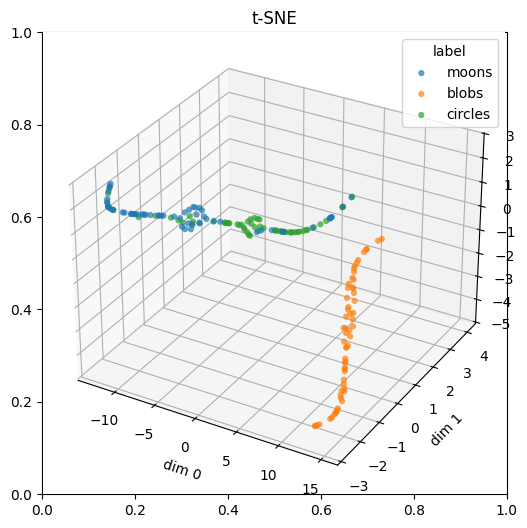

In [9]:
vis = EmbeddingVisualizer(random_state=42)
fig, ax = vis.plot(
    test_embeddings,
    labels=test_labels,
    method="tsne",
    title="t-SNE",
    n_components=3,
    show=True,
)


## 5. Confusion matrices in embedding space


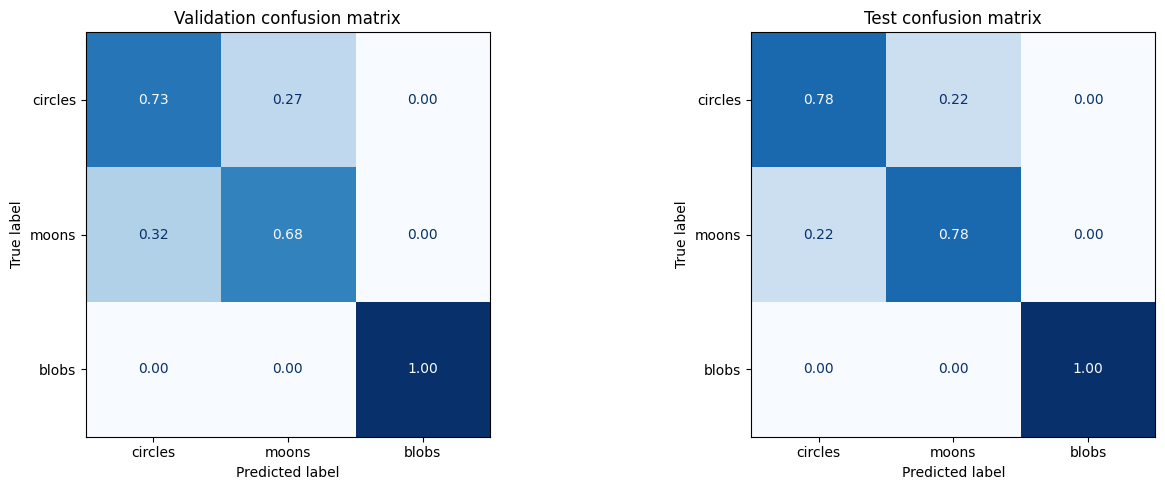

Validation accuracy: 0.806
              precision    recall  f1-score   support

     circles      0.698     0.733     0.715        60
       moons      0.719     0.683     0.701        60
       blobs      1.000     1.000     1.000        60

    accuracy                          0.806       180
   macro avg      0.806     0.806     0.805       180
weighted avg      0.806     0.806     0.805       180

Test accuracy: 0.856
              precision    recall  f1-score   support

     circles      0.783     0.783     0.783        60
       moons      0.783     0.783     0.783        60
       blobs      1.000     1.000     1.000        60

    accuracy                          0.856       180
   macro avg      0.856     0.856     0.856       180
weighted avg      0.856     0.856     0.856       180



In [10]:
def predict_by_nearest_centroid(
    embeddings: np.ndarray,
    centroids: dict[str, np.ndarray],
) -> np.ndarray:
    centroid_matrix = np.vstack([centroids[label] for label in DATASET_TYPES])
    distances = np.linalg.norm(embeddings[:, None, :] - centroid_matrix[None, :, :], axis=2)
    return np.asarray(DATASET_TYPES)[distances.argmin(axis=1)]


val_predictions = predict_by_nearest_centroid(val_embeddings, train_centroids)
test_predictions = predict_by_nearest_centroid(test_embeddings, train_centroids)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, split_name, y_true, y_pred in [
    (axes[0], "Validation", val_labels, val_predictions),
    (axes[1], "Test", test_labels, test_predictions),
]:
    cm = confusion_matrix(y_true, y_pred, labels=DATASET_TYPES, normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=DATASET_TYPES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
    ax.set_title(f"{split_name} confusion matrix")

plt.tight_layout()
plt.show()

print(f"Validation accuracy: {(np.asarray(val_labels) == val_predictions).mean():.3f}")
print(classification_report(val_labels, val_predictions, labels=list(DATASET_TYPES), digits=3, zero_division=0))

print(f"Test accuracy: {(np.asarray(test_labels) == test_predictions).mean():.3f}")
print(classification_report(test_labels, test_predictions, labels=list(DATASET_TYPES), digits=3, zero_division=0))
